# JSE Sector Momentum Strategy — Research Notebook
## Stage 1: Environment Setup & Data Collection

### Objective
Set up a clean, reproducible Python environment and pull the first 
dataset needed for the JSE Sector Momentum Strategy research project.

### Environment
- OS: Windows
- Python: 3.13.7
- Virtual Environment: venv (located in project root)
- Editor: VS Code with Jupyter extension

### Libraries Installed
- yfinance 1.2.1 — financial data from Yahoo Finance
- pandas 3.0.2 — data manipulation and time series handling
- matplotlib 3.10.8 — charting and visualisation

### Activation Command (run in terminal each time you return to project)
cd "G:\My Drive\jse-sector-momentum"
venv\Scripts\activate
code .

### Data Collected
- Ticker: ^J203.JO (JSE All Share Index)
- Source: Yahoo Finance via yfinance
- Period: 2019-01-01 to 2026-04-10
- Rows: 1,817 trading days
- Columns: Close, High, Low, Open, Volume

### Key Observations
- ALSI moved from approximately 50,000 to 130,000 over the period
- COVID crash visible in March 2020
- Data quality issue detected, they were two stray figures which were handled by interpolation.

### Output 
- data/jse_alsi_prices_clean_2019_2026.csv - alsi clean daily price data from 2019 to 2026

### Files in this Stage
- 01_data_collection.ipynb — this notebook

# JSE Sector Momentum Strategy
## Step 1 — ALSI Data Collection & Environment Setup
Data source: Yahoo Finance via yfinance  
Index: JSE All Share Index (^J203.JO)  
Period: January 2019 to April 2026

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("Liabraries Loaded Successfully")
print( f"pandas version: {pd.__version__}")
print( f"yfinance version: {yf.__version__}")


Liabraries Loaded Successfully
pandas version: 3.0.2
yfinance version: 1.2.1


In [2]:
alsi = yf.download("^J203.JO", start = "2019-01-01", end = "2026-04-10")
print(alsi.shape)
print(alsi.head())

[*********************100%***********************]  1 of 1 completed

(1817, 5)
Price              Close          High           Low          Open   Volume
Ticker          ^J203.JO      ^J203.JO      ^J203.JO      ^J203.JO ^J203.JO
Date                                                                       
2019-01-02  51264.058594  52736.859375  50907.449219  52736.859375        0
2019-01-03  51669.941406  51870.898438  51135.199219  51264.058594        0
2019-01-04  52202.949219  52202.949219  51654.191406  51669.941406        0
2019-01-07  51959.300781  53199.031250  51813.738281  52202.949219        0
2019-01-08  52165.468750  52341.519531  51959.300781  51959.300781        0


## Step 2 — ALSI Data visualisation

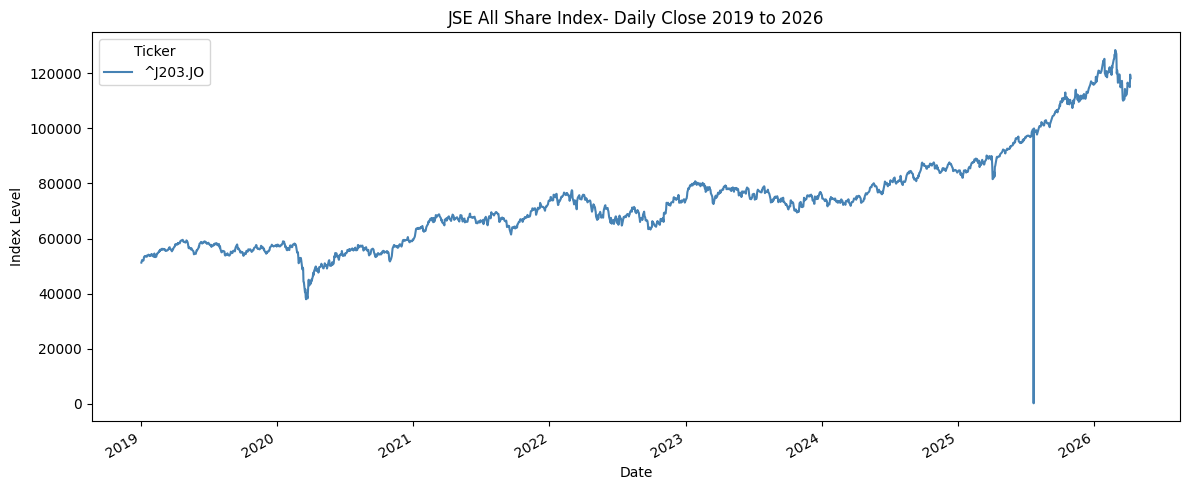

In [3]:
alsi["Close"]. plot(
    figsize=(12,5),
    title = "JSE All Share Index- Daily Close 2019 to 2026",
    color = "steelblue"
)
plt.ylabel("Index Level")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## Step 3 — ALSI Data Cleaning

In [5]:
#Find the Suspicion value inConsumer Goodds
# Any value below 10,000 is likely wrong given the range
mask = alsi["Close"]< 10000
alsi.columns = [col[0] for col in alsi.columns]
print(alsi.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [6]:
# Now find suspicious values
alsi_returns = alsi["Close"].pct_change() * 100
abnormal = alsi_returns[alsi_returns.abs() > 10]
print(abnormal)

Date
2025-07-23      -99.818977
2025-07-24    55501.287815
Name: Close, dtype: float64


In [9]:
for date in abnormal.index:
    alsi.loc[date, "Close"] = None

#Interpolate to fill gap
alsi["Close"] = alsi["Close"].interpolate(method = "linear")

for date in abnormal.index:
    print(f"Value on {date.date()} was corrected to {alsi.loc[date, 'Close']:.2f}")




Value on 2025-07-23 was corrected to 99189.31
Value on 2025-07-24 was corrected to 99054.09


## Step 4 — ALSI Clean Data Viewing and Saving

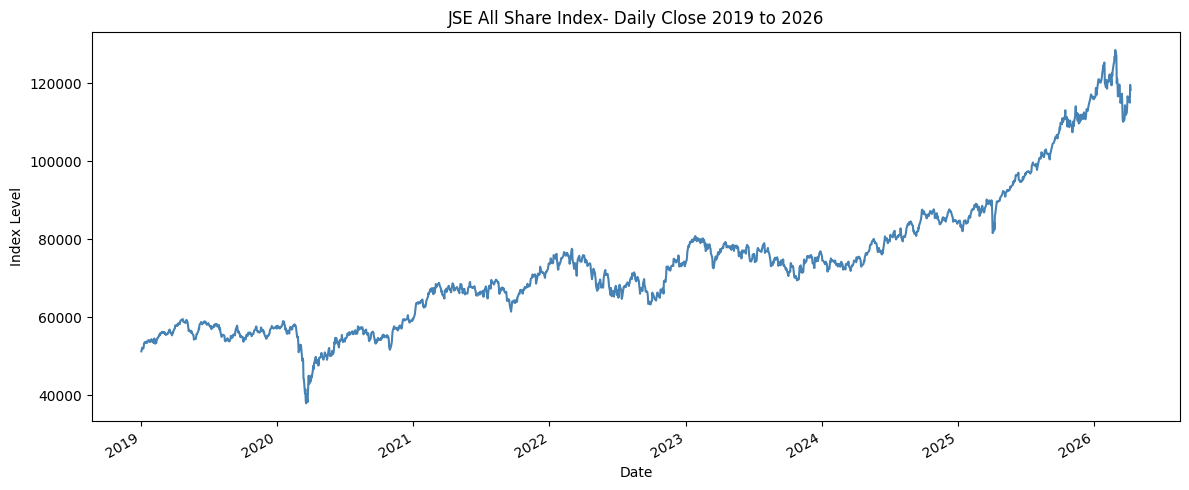

In [8]:
alsi["Close"]. plot(
    figsize=(12,5),
    title = "JSE All Share Index- Daily Close 2019 to 2026",
    color = "steelblue"
)
plt.ylabel("Index Level")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [10]:
alsi.to_csv("data/jse_alsi_prices_clean_2019_2026.csv")
print("Saved alsi data to CSV successfully")

Saved alsi data to CSV successfully
